# Chapter 13. Barren Plateau와 표현력

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 2**

## 학습 목표
- 큐비트 수에 따라 gradient의 분산이 어떻게 줄어드는지 실험으로 확인
- 무작위 회로에서 손실 평면이 평탄해지는 현상 시각화
- 완화 전략(local cost) 비교

In [1]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 13.1 Gradient variance vs 큐비트 수
무작위 깊은 회로에서 한 파라미터에 대한 gradient를 100번 샘플링하여 분산을 측정한다.

In [2]:
n_samples = 30
n_layers = 4
rng = np.random.RandomState(42)

def measure_gradient_variance(n_qubits, cost_type='global'):
    dev = qml.device('default.qubit', wires=n_qubits)

    obs = qml.PauliZ(0) @ qml.PauliZ(n_qubits - 1) if cost_type == 'global' else qml.PauliZ(0)
    # local: 큐비트 0의 Z만, global: 양끝 Z⊗Z

    @qml.qnode(dev, interface='autograd')
    def circuit(weights):
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return qml.expval(obs)

    shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
    grad_samples = []
    for _ in range(n_samples):
        w = pnp.array(rng.uniform(0, 2 * np.pi, shape), requires_grad=True)
        # 첫 번째 파라미터에 대한 gradient만 추출
        g = qml.grad(circuit)(w)
        grad_samples.append(float(g.flatten()[0]))
    return np.var(grad_samples)

qubit_range = [2, 3, 4, 5]
vars_global = [measure_gradient_variance(n, 'global') for n in qubit_range]
vars_local = [measure_gradient_variance(n, 'local') for n in qubit_range]

print('n_qubits  Var(grad) global  Var(grad) local')
for n, vg, vl in zip(qubit_range, vars_global, vars_local):
    print(f'{n:<10}{vg:<18.5f}{vl:<.5f}')

n_qubits  Var(grad) global  Var(grad) local
2         0.00000           0.00000
3         0.00000           0.00000
4         0.00000           0.00000
5         0.00000           0.00000


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

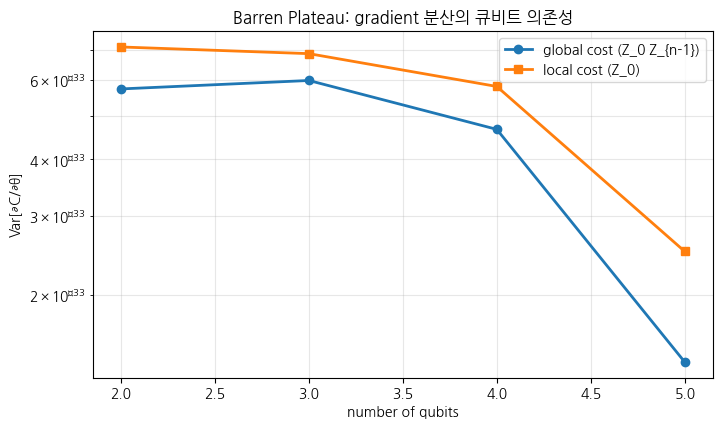

In [3]:
plt.figure(figsize=(8, 4.5))
plt.semilogy(qubit_range, vars_global, 'o-', lw=2, label='global cost (Z_0 Z_{n-1})')
plt.semilogy(qubit_range, vars_local, 's-', lw=2, label='local cost (Z_0)')
plt.xlabel('number of qubits')
plt.ylabel('Var[∂C/∂θ]')
plt.title('Barren Plateau: gradient 분산의 큐비트 의존성')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.show()

**관찰.** Global cost에서 분산이 큐비트 수에 따라 빠르게(거의 지수적으로) 감소한다. Local cost는 상대적으로 분산이 천천히 줄어든다 — 이것이 "local cost trick"이다.

## 13.2 손실 곡면 시각화 (n=5)
두 파라미터를 고정하지 않고 변화시켜 손실 곡면을 그려본다.

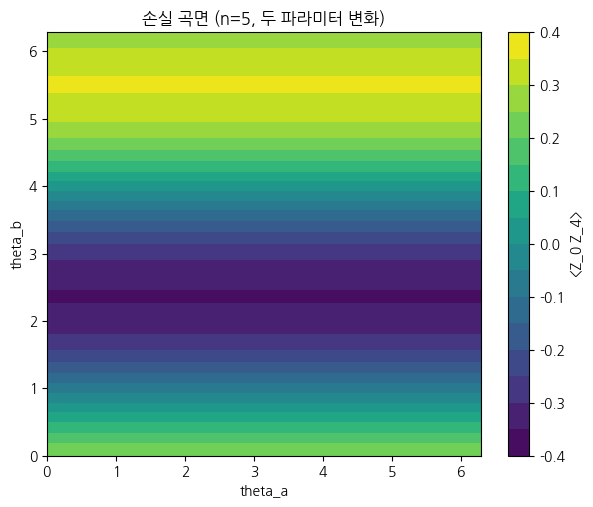

In [4]:
n_qubits = 5
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev)
def landscape_circuit(theta_a, theta_b):
    # 무작위 고정 부분
    for w in range(n_qubits):
        qml.RY(np.pi / 4, wires=w)
    # 가변 두 파라미터
    qml.RY(theta_a, wires=0)
    qml.RY(theta_b, wires=1)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n_qubits - 1))

grid = np.linspace(0, 2 * np.pi, 30)
ta, tb = np.meshgrid(grid, grid)
Z = np.array([[landscape_circuit(a, b) for a, b in zip(row_a, row_b)] for row_a, row_b in zip(ta, tb)])

plt.figure(figsize=(7, 5.5))
plt.contourf(ta, tb, Z, levels=15, cmap='viridis')
plt.colorbar(label='<Z_0 Z_4>')
plt.xlabel('theta_a'); plt.ylabel('theta_b')
plt.title('손실 곡면 (n=5, 두 파라미터 변화)')
plt.show()

## 13.3 노이즈 채널과 NISQ 현실성
실제 양자 하드웨어는 항상 노이즈가 있다. PennyLane의 `default.mixed` 디바이스는 노이즈 채널(bit-flip, depolarizing, amplitude-damping)을 시뮬레이션할 수 있다. 이 절에서는 노이즈가 회로 출력에 어떻게 영향을 주는지, 그리고 **노이즈 파라미터 자체를 데이터로부터 학습**할 수 있음을 보여준다.

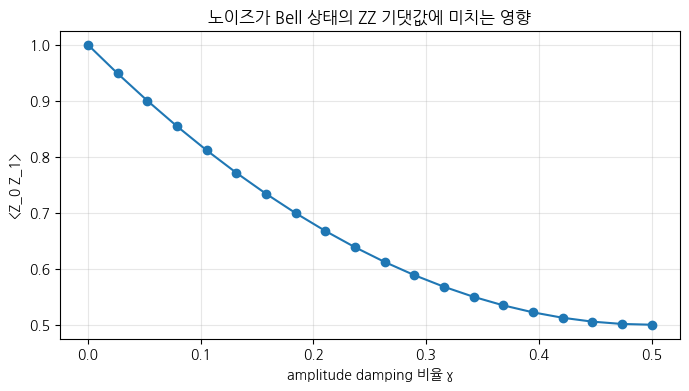

γ=0  (noiseless): <ZZ> = 1.0000
γ=0.5         : <ZZ> = 0.5000


In [5]:
# default.mixed로 노이즈 시뮬레이션
dev_noisy = qml.device('default.mixed', wires=2)

@qml.qnode(dev_noisy)
def noisy_circuit(noise_param):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    # 두 큐비트에 amplitude damping 적용 (T1 decay 모델)
    qml.AmplitudeDamping(noise_param, wires=0)
    qml.AmplitudeDamping(noise_param, wires=1)
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

# 노이즈 비율에 따른 ZZ 기댓값 변화
noise_levels = np.linspace(0, 0.5, 20)
expvals = [noisy_circuit(p) for p in noise_levels]

plt.figure(figsize=(8, 4))
plt.plot(noise_levels, expvals, 'o-')
plt.xlabel('amplitude damping 비율 γ')
plt.ylabel('<Z_0 Z_1>')
plt.title('노이즈가 Bell 상태의 ZZ 기댓값에 미치는 영향')
plt.grid(alpha=0.3); plt.show()
print(f'γ=0  (noiseless): <ZZ> = {expvals[0]:.4f}')
print(f'γ=0.5         : <ZZ> = {expvals[-1]:.4f}')

**관찰.** 노이즈가 없으면 Bell 상태에서 ⟨ZZ⟩ = 1이지만, amplitude damping이 커질수록 1보다 작아진다. 이는 얽힘이 점점 파괴되는 모습이다.

### 13.3.1 노이즈 파라미터 역추정
관측된 측정값들로부터 노이즈율을 추정한다. 이것은 실제 양자 디바이스 캐릭터라이제이션의 핵심 기법이다.

관측 평균 <ZZ>: 0.7137
관측 표준편차:  0.0216


/opt/miniconda3/envs/qml/lib/python3.10/site-packages/autograd/numpy/numpy_wrapper.py:187: ComplexWarning: Casting complex values to real discards the imaginary part
  return A.astype(dtype, order, casting, subok, copy)


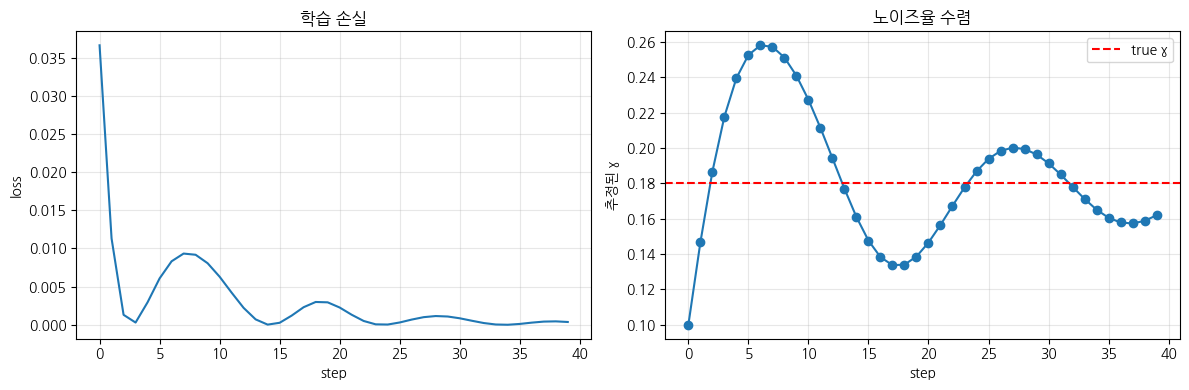

진짜 γ:    0.1800
추정 γ:    0.1619
추정 오차: 0.0181


In [6]:
# 실험에서 관측된 (가상) 데이터: 알려지지 않은 노이즈율로 얻은 측정값
true_gamma = 0.18  # 우리가 찾아야 할 진짜 노이즈율
rng = np.random.RandomState(0)
n_obs = 30
observed_zz = noisy_circuit(true_gamma) + 0.02 * rng.randn(n_obs)
print(f'관측 평균 <ZZ>: {observed_zz.mean():.4f}')
print(f'관측 표준편차:  {observed_zz.std():.4f}')

# 노이즈율을 학습 가능한 파라미터로 두고 학습
from pennylane import numpy as pnp

@qml.qnode(dev_noisy, interface='autograd')
def model_with_noise(gamma):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.AmplitudeDamping(gamma, wires=0)
    qml.AmplitudeDamping(gamma, wires=1)
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

def loss(gamma):
    pred = model_with_noise(gamma)
    return (pred - observed_zz.mean()) ** 2

gamma_param = pnp.array(0.05, requires_grad=True)  # 초기 추정
opt = qml.AdamOptimizer(0.05)
history = []
for step in range(40):
    gamma_param, c = opt.step_and_cost(loss, gamma_param)
    # gamma는 [0, 1] 범위로 클리핑
    gamma_param = pnp.array(np.clip(float(gamma_param), 0, 1), requires_grad=True)
    history.append((float(gamma_param), c))

gammas, losses = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses); axes[0].set_xlabel('step'); axes[0].set_ylabel('loss')
axes[0].set_title('학습 손실'); axes[0].grid(alpha=0.3)
axes[1].plot(gammas, 'o-'); axes[1].axhline(true_gamma, color='red', ls='--', label='true γ')
axes[1].set_xlabel('step'); axes[1].set_ylabel('추정된 γ')
axes[1].set_title('노이즈율 수렴'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'진짜 γ:    {true_gamma:.4f}')
print(f'추정 γ:    {gammas[-1]:.4f}')
print(f'추정 오차: {abs(gammas[-1] - true_gamma):.4f}')

**핵심 메시지.** 양자 회로의 파라미터뿐 아니라 **노이즈 모델 자체도 학습 대상**이 될 수 있다. 이것이 양자 디바이스 캐릭터라이제이션과 에러 완화(error mitigation)의 출발점이다.

**관련 후속 주제:**
- **Zero-noise extrapolation (ZNE)**: 의도적으로 노이즈를 키우며 측정하고 γ=0으로 외삽
- **Probabilistic error cancellation (PEC)**: 노이즈 모델의 역을 적용해 통계적으로 노이즈 제거
- **Variational error mitigation**: 변분 회로로 노이즈를 흡수하는 추가 layer 학습

## 13.4 정리
- 무작위 깊은 회로에서 gradient의 분산은 큐비트 수에 지수적으로 감소한다.
- Local cost 함수를 쓰면 이 문제를 부분적으로 완화할 수 있다.
- 실제 NISQ 디바이스의 노이즈는 `default.mixed`로 시뮬레이션 가능하다.
- 노이즈 파라미터도 학습 가능한 변수로 다룰 수 있어 디바이스 캐릭터라이제이션이 가능하다.
- 다음 챕터(QGAN)와 마지막 챕터(Geometric QML)에서 추가 완화 전략을 다룬다.